In [1]:
# Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import glob
from scipy.optimize import curve_fit
import seaborn as sns
%matplotlib inline

Text(0, 0.5, 'log r0')

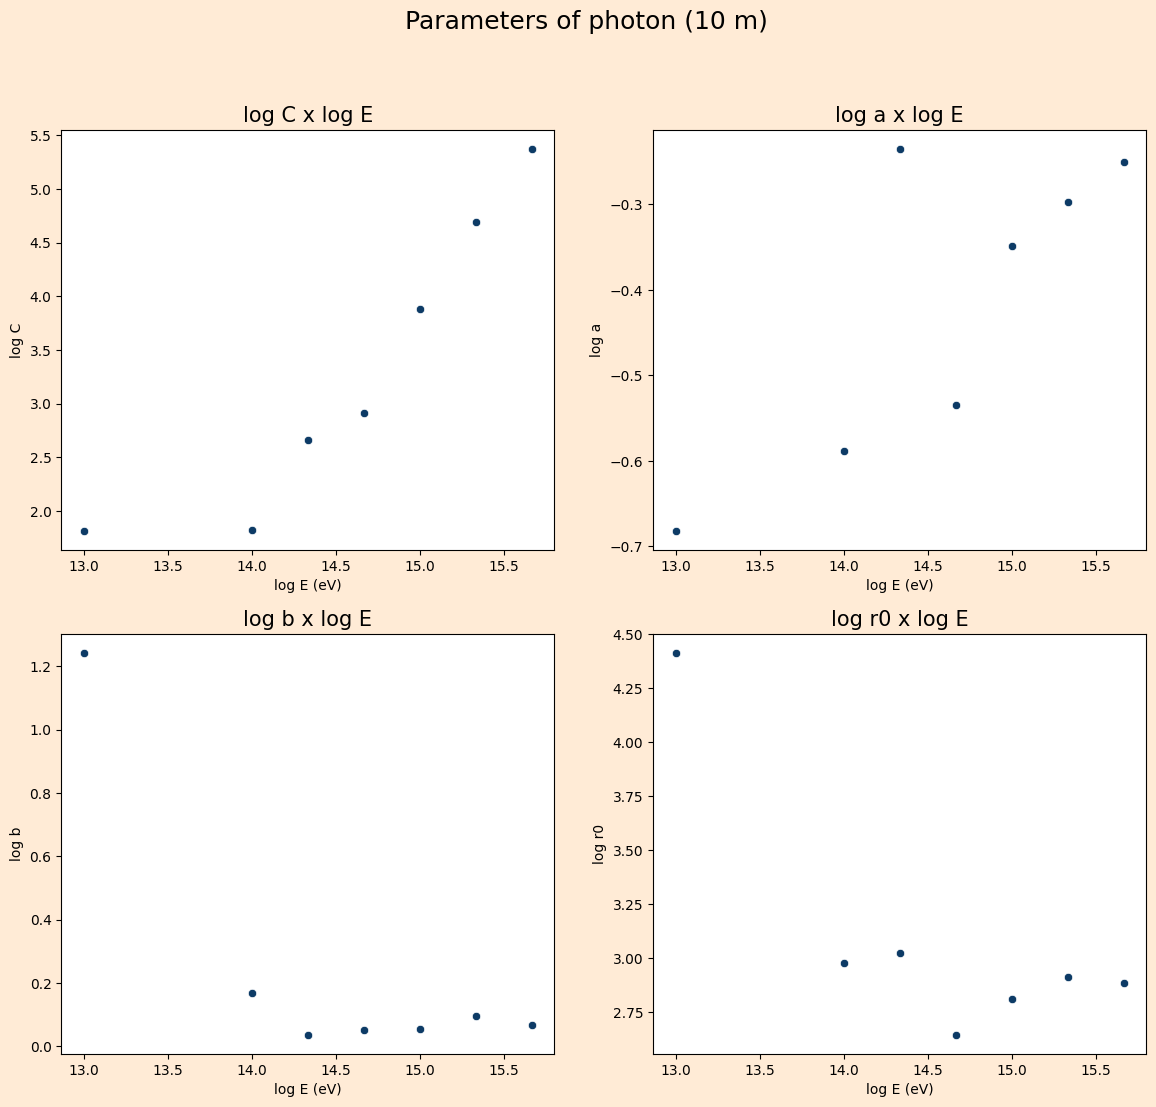

In [7]:
# Fóton

C = [6.56049e+01,66.38,459,813.4,7536,4.9E4,2.358E5]
a = [2.08110e-01,0.2577,0.5818,0.2917,0.4475,0.5048,0.561]
b = [1.74817e+01,1.474,1.089,1.127,1.131,1.244,1.17]
r0 = [2.58997e+04,953.2,1061,443.8,648.6,822,765.4]
E = [1E13,1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [2.11947e-05,0.00608937,0.0763921,0.250482,1.73749,9.03232,54.1215]


logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala


/tmp/ipykernel_14519/3638320968.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[4.50459680e-28 1.26149178e-01]
[1.78464784 2.49145092 3.20174309 3.9107649  4.61756798 5.32786015]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.822037,14.0,14.017586,0.125613
2.661813,14.332438,14.412567,0.559068
2.910304,14.666518,14.529442,0.934616
3.877141,15.0,14.984185,0.105432
4.690196,15.332438,15.366598,0.222795
5.372544,15.666518,15.687535,0.134149


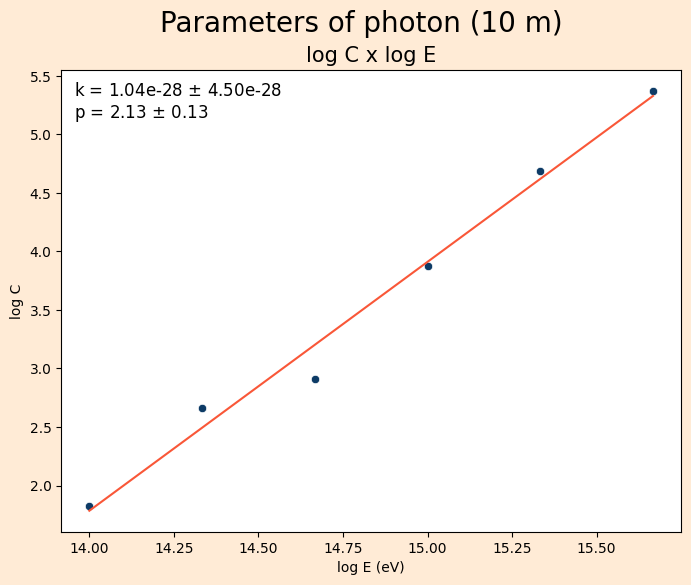

In [8]:
# Fit do fóton

C = [66.38,459,813.4,7536,4.9E4,2.358E5]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

Text(0, 0.5, 'log r0')

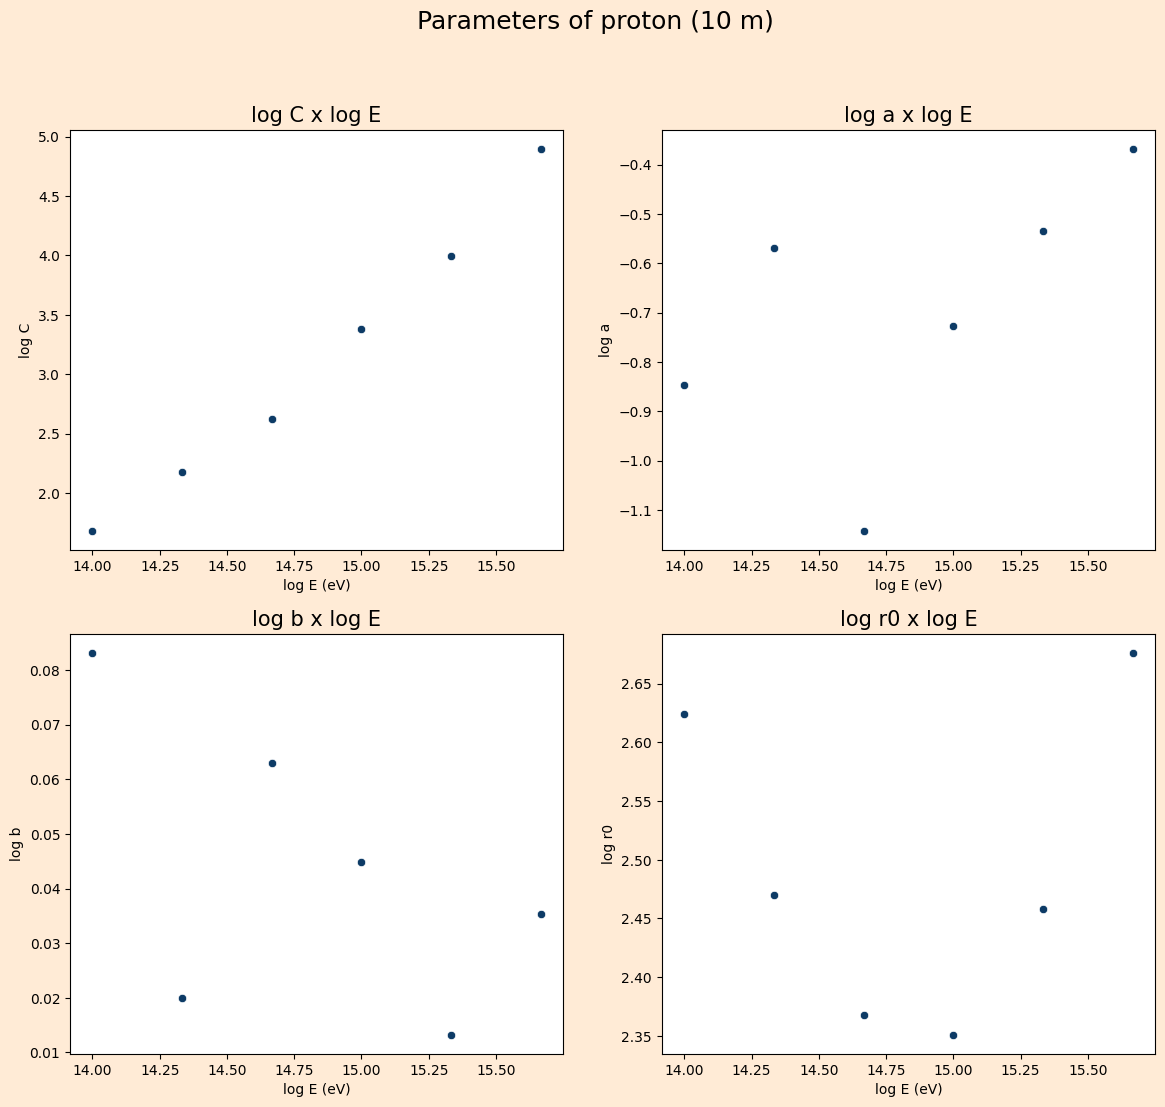

In [9]:
# Próton

#C = [24.58,48.24,148.9,419.5,2420,9926,7.903E4]
#a = [-0.3584,0.1421, 0.2698,0.0721, 0.1878,0.2916,0.4288]
#b = [5.401,1.211, 1.047,1.156, 1.109,1.031,1.085]
#r0 = [2661,420.9,294.9,233.4,224.4, 287.3,474.6]
#E = [1E13,1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
#D = [7.72213e-05,0.0136873,0.0804352,0.265194,1.72513,5.66541,26.6964] # Densidade (Integral do gráfico)

C = [48.24,148.9,419.5,2420,9926,7.903E4]
a = [0.1421, 0.2698,0.0721, 0.1878,0.2916,0.4288]
b = [1.211, 1.047,1.156, 1.109,1.031,1.085]
r0 = [420.9,294.9,233.4,224.4, 287.3,474.6]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.0136873,0.0804352,0.265194,1.72513,5.66541,26.6964]

logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala


/tmp/ipykernel_14519/2368344500.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[2.25450517e-25 1.13019449e-01]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
1.683407,14.0,14.078353,0.559664
2.172895,14.332438,14.334366,0.01345
2.622732,14.666518,14.569641,0.660529
3.383815,15.0,14.967705,0.215297
3.996774,15.332438,15.288297,0.287896
4.897792,15.666518,15.75955,0.593827


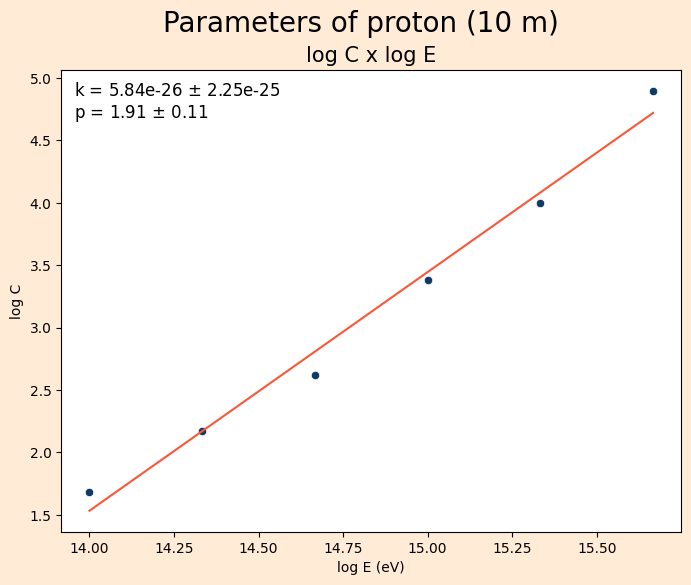

In [10]:
# Fit do próton

C = [48.24,148.9,419.5,2420,9926,7.903E4]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_14519/949303982.py:11: RuntimeWarning: invalid value encountered in log10
  loga = np.log10(a)


Text(0, 0.5, 'log r0')

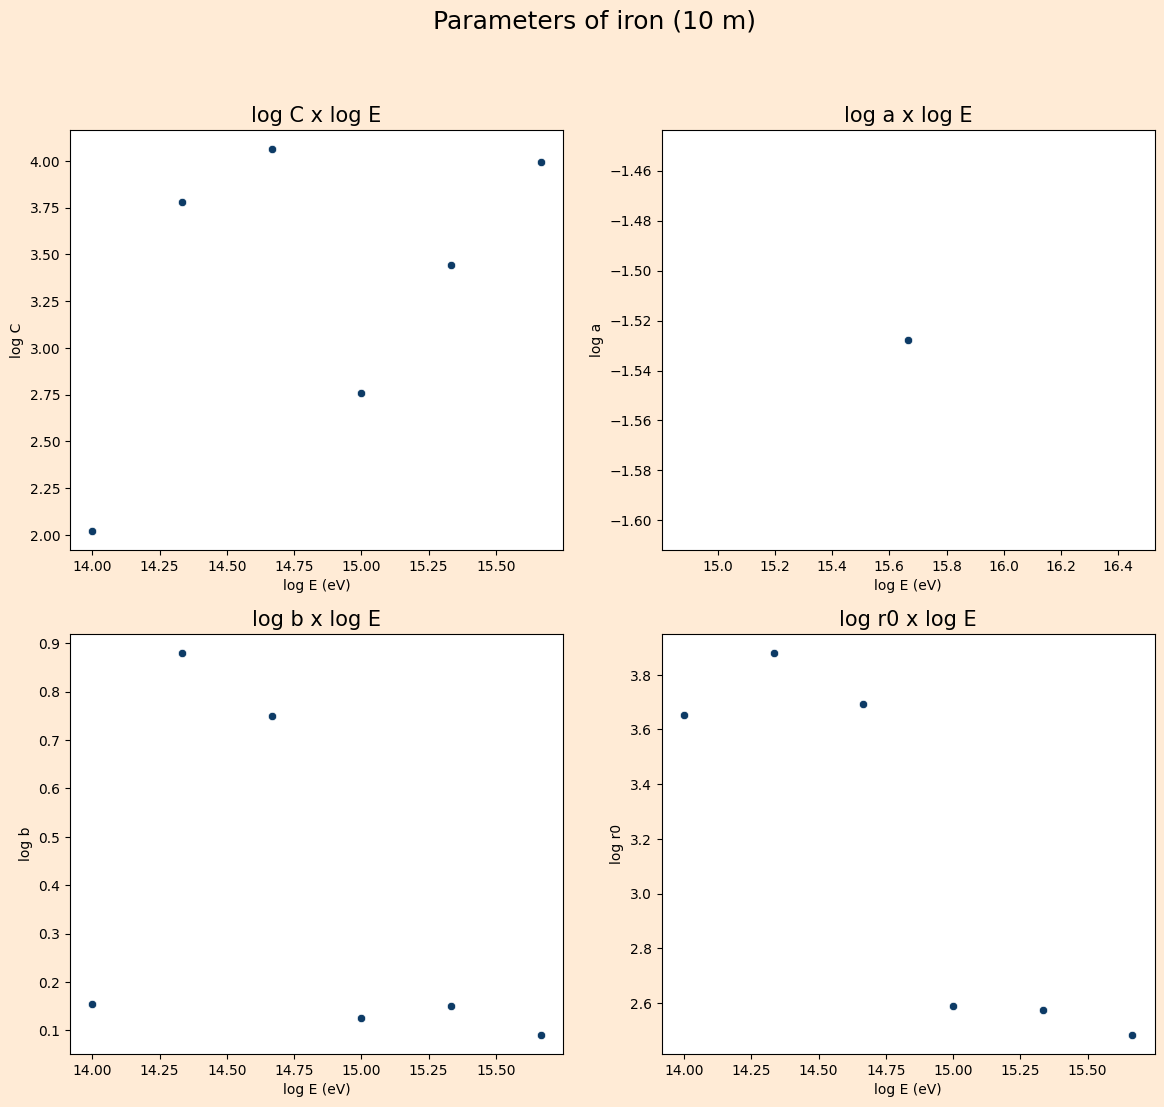

In [16]:
# Ferro

C = [105.4,6027,1.161E4,574.5,2793,9926]
a = [-0.0993,-0.2855,-0.1371,-0.1176,-0.1058,0.02967]
b = [1.431,7.592,5.633,1.333,1.411,1.234]
r0 = [4509,7590,4947,387.2,373.6,304.8]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.000386369,0.00300455,0.0201856,0.14641,0.717294,4.04014]

logC = np.log10(C)
loga = np.log10(a)
logb = np.log10(b)
logr0 = np.log10(r0)
logE = np.log10(E)


fig, ax = plt.subplots(2, 2, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = loga, ax = ax[0,1], color = '#0D3B66')
sns.scatterplot(x = logE, y = logb, ax = ax[1,0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logr0, ax = ax[1,1], color = '#0D3B66')

ax[0,0].set_title('log C x log E', size = 15)
ax[0,0].set_xlabel('log E (eV)')
ax[0,0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[0,1].set_title('log a x log E', size = 15)
ax[0,1].set_xlabel('log E (eV)')
ax[0,1].set_ylabel('log a')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

ax[1,0].set_title('log b x log E', size = 15)
ax[1,0].set_xlabel('log E (eV)')
ax[1,0].set_ylabel('log b')
#ax[1,0].set_xscale('log')
#ax[1,0].set_yscale('log')

ax[1,1].set_title('log r0 x log E', size = 15)
ax[1,1].set_xlabel('log E (eV)')
ax[1,1].set_ylabel('log r0')
#ax[1,1].set_xscale('log')
#ax[1,1].set_yscale('log')

#yticks - numeros na escala

/tmp/ipykernel_14519/1026357065.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.03480983e-05 5.57546576e-01]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.022841,14.0,12.792289,8.626509
3.780101,14.332438,15.504577,8.178219
4.064832,14.666518,15.944052,8.710547
2.75929,15.0,13.92898,7.140133
3.446071,15.332438,14.989009,2.239886
3.996774,15.666518,15.839006,1.100999


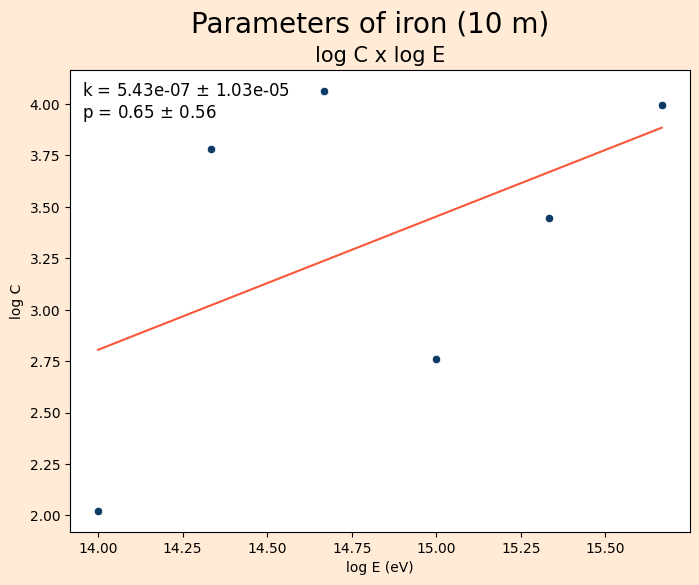

In [17]:
# Fit do ferro

C = [105.4,6027,1.161E4,574.5,2793,9926]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_30374/2696788569.py:77: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[4.04624474e-15 2.42045339e-02]


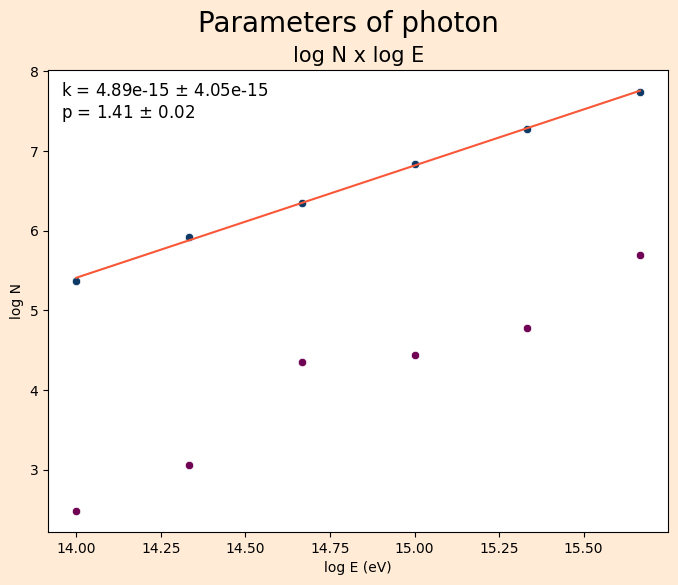

In [2]:
# Relação entre C e o número total de partículas (N)

# Fóton


C = [48.24,148.9,419.5,2420,9926,7.903E4]
a = [0.2577,0.5818,0.2917,0.4475,0.5048,0.561]
b = [1.474,1.089,1.127,1.131,1.244,1.17]
r0 = [2.58997e+04,953.2,1061,443.8,648.6,822,765.4]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
s = []
N_t = []
C_s = []
N_s = []

for i in range(len(a)):
    aux = (5.5 - a[i] - b[i])/2
    s.append(aux)

for i in range(len(C)):
    aux1 = 0.366*s[i]**2*(2.07-s[i])**1.25
    C_s.append(aux1)

for i  in range(len(C)):
    aux2 = C[i]/C_s[i]
    N_s.append(aux2)  

output_path = '/home/orfei/mestrado/progs/lateral_distribution/photon/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df

logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)



fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


/tmp/ipykernel_14519/3626607367.py:58: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[6.43575901e-12 1.80286337e-02]


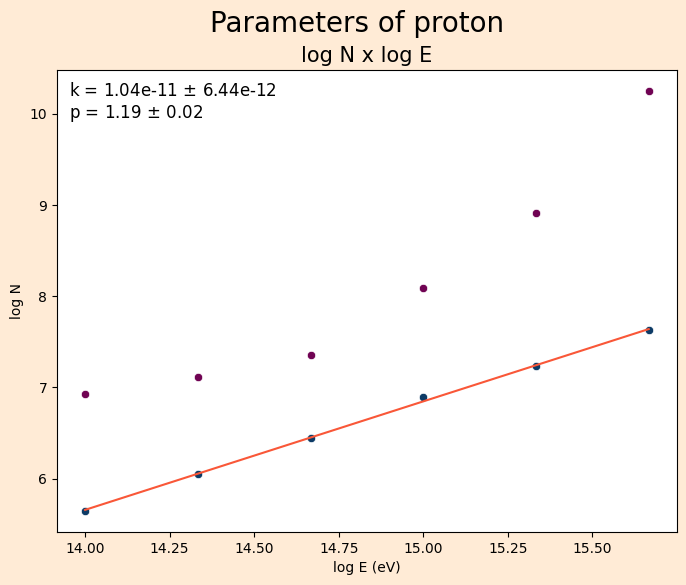

In [27]:
# Relação entre C e o número total de partículas (N)

# Próton


C = [48.24,148.9,419.5,2420,9926,7.903E4]
r0 = [420.9,294.9,233.4,224.4, 287.3,474.6]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
N_t = []
N_s = []

for i in range(len(C)):
    aux = C[i]*r0[i]**2
    N_s.append(aux)

output_path = '/home/orfei/mestrado/progs/lateral_distribution/proton/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df

logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)

/tmp/ipykernel_14519/111742911.py:59: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[1.72017716e-11 1.62789612e-02]


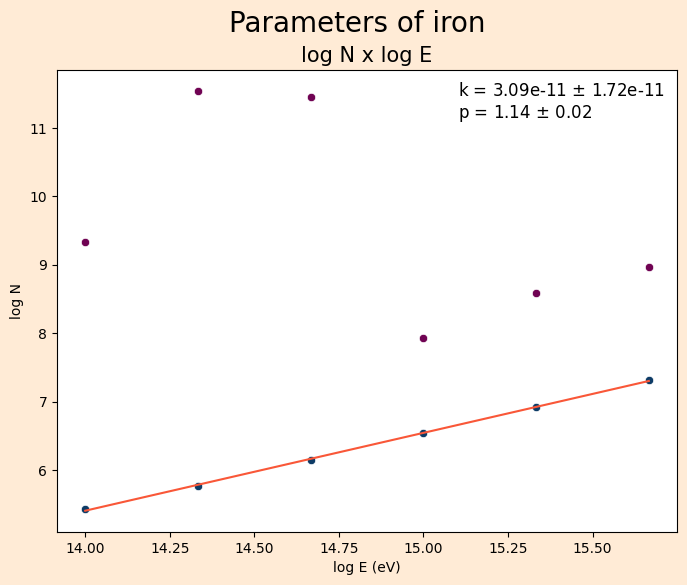

In [28]:
# Relação entre C e o número total de partículas (N)

# Ferro


C = [105.4,6027,1.161E4,574.5,2793,9926]
r0 = [4509,7590,4947,387.2,373.6,304.8]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
N_t = []
N_s = []

for i in range(len(C)):
    aux = C[i]*r0[i]**2
    N_s.append(aux)

output_path = '/home/orfei/mestrado/progs/lateral_distribution/iron/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df


logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)